In [6]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
text ="Natural Language Processing (NLP) is a branch of Artificial Intelligence that helps computers understand, interpret, and generate human language."
text =text.lower()
# Modified regex to preserve spaces, then normalize multiple spaces
text =re.sub(r'[^a-zA-Z\s]', '',text)
text =re.sub(r'\s+', ' ', text).strip()

tokens =word_tokenize(text)
cleaned =[word for word in tokens if word not in stopwords.words('english')]
print(cleaned)

['natural', 'language', 'processing', 'nlp', 'branch', 'artificial', 'intelligence', 'helps', 'computers', 'understand', 'interpret', 'generate', 'human', 'language']


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
import string

text = "Hello, world! How are you today?"

# Remove punctuation
clean_text = text.translate(str.maketrans('', '', string.punctuation))

print(clean_text)

Hello world How are you today


In [7]:
from nltk.tokenize import word_tokenize

tokens = word_tokenize(clean_text)
print(tokens)

['Hello', 'world', 'How', 'are', 'you', 'today']


In [8]:
print(cleaned)

['natural', 'language', 'processing', 'nlp', 'branch', 'artificial', 'intelligence', 'helps', 'computers', 'understand', 'interpret', 'generate', 'human', 'language']


In [11]:
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
lemmatized_tokens = [lemmatizer.lemmatize(word) for word in cleaned]

print(lemmatized_tokens)

['natural', 'language', 'processing', 'nlp', 'branch', 'artificial', 'intelligence', 'help', 'computer', 'understand', 'interpret', 'generate', 'human', 'language']


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [14]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


Saving IMDB Dataset.csv (2).zip to IMDB Dataset.csv (2).zip
User uploaded file "IMDB Dataset.csv (2).zip" with length 26962657 bytes


In [21]:
import zipfile

zip_path = '/content/IMDB Dataset.csv (2).zip'
extract_path = '/content/imdb_data'

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print(f'Extraction completed to {extract_path}!')

Extraction completed to /content/imdb_data!


In [13]:
!ls -F /content/

sample_data/


In [16]:
import pandas as pd
df=pd.read_csv('/IMDB Dataset.csv (2).zip')

In [18]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [23]:
print(f"DataFrame shape before removing duplicates: {df.shape}")
df.drop_duplicates(inplace=True)
print(f"DataFrame shape after removing duplicates: {df.shape}")

DataFrame shape before removing duplicates: (50000, 2)
DataFrame shape after removing duplicates: (49582, 2)


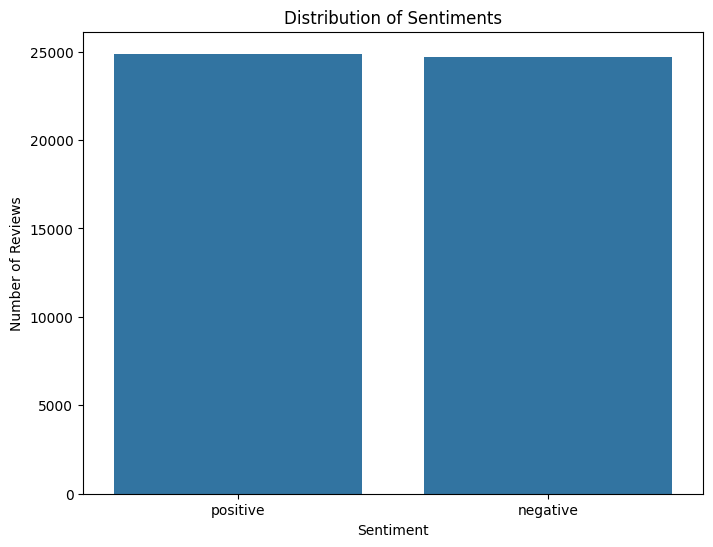

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='sentiment')
plt.title('Distribution of Sentiments')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')
plt.show()

Shape of X_train: (39665,)
Shape of X_test: (9917,)
Shape of y_train: (39665,)
Shape of y_test: (9917,)


### Text Preprocessing

Now, let's preprocess the review text in both the training and testing sets. This involves:
1.  **Lowercasing**: Converting all text to lowercase.
2.  **Removing Special Characters**: Using regular expressions to remove non-alphabetic characters and numbers, while preserving spaces.
3.  **Tokenization**: Splitting the text into individual words.
4.  **Stopword Removal**: Eliminating common words (like 'the', 'is', 'a') that don't add much meaning for sentiment analysis.
5.  **Lemmatization**: Reducing words to their base or root form (e.g., 'running' to 'run', 'better' to 'good').

In [26]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize NLTK components
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Removing Special Characters (keep letters and spaces)
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 3. Tokenization
    tokens = word_tokenize(text)

    # 4. Stopword Removal and 5. Lemmatization
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]

    # Join tokens back into a string
    return ' '.join(processed_tokens)

# Apply preprocessing to training and testing sets
X_train_preprocessed = X_train.apply(preprocess_text)
X_test_preprocessed = X_test.apply(preprocess_text)

print("Preprocessing complete!")

Preprocessing complete!


In [27]:
print("Original X_train (first 2 reviews):")
print(X_train.head(2).to_list())
print("\nPreprocessed X_train (first 2 reviews):")
print(X_train_preprocessed.head(2).to_list())

print("\nOriginal X_test (first 2 reviews):")
print(X_test.head(2).to_list())
print("\nPreprocessed X_test (first 2 reviews):")
print(X_test_preprocessed.head(2).to_list())

Original X_train (first 2 reviews):
['I really liked the movie \'The Emporer\'s New Groove\', but watching this was like coming home and seeing your wife having "relations" with a llama. Seriously, this movie was bad. It\'s like Club Dread after Super Troopers. I am supposed to write 10 lines, but I don\'t even know what else to say. I laughed a couple of times, but only because I was drinking. A movie like that should at least be funny when your drunk. It was not. Maybe llamas are just funny and regular cartoon people aren\'t. Either way, just stick with The Emporer\'s New Groove if you want a funny, cartoon, llama-themed movie. Line 10 is this line right here.', 'I decided to watch this movie because it has been noted as the "scariest movie ever" so, that\'s what I expected. Unfortunately, what I found out is that the movie didn\'t have a single scary moment in it (and I\'m the kind of person who jumps very easily). The movie was nothing but terrible clichés and every time there was 

In [29]:
from nltk.tokenize import word_tokenize

# Tokenize a sample of the preprocessed training data
sample_train_review_tokens = word_tokenize(X_train_preprocessed.iloc[0])
print("Sample of preprocessed and tokenized training review:")
print(sample_train_review_tokens)

# Tokenize a sample of the preprocessed testing data
sample_test_review_tokens = word_tokenize(X_test_preprocessed.iloc[0])
print("\nSample of preprocessed and tokenized testing review:")
print(sample_test_review_tokens)


Sample of preprocessed and tokenized training review:
['really', 'liked', 'movie', 'emporers', 'new', 'groove', 'watching', 'like', 'coming', 'home', 'seeing', 'wife', 'relation', 'llama', 'seriously', 'movie', 'bad', 'like', 'club', 'dread', 'super', 'trooper', 'supposed', 'write', 'line', 'dont', 'even', 'know', 'else', 'say', 'laughed', 'couple', 'time', 'drinking', 'movie', 'like', 'least', 'funny', 'drunk', 'maybe', 'llama', 'funny', 'regular', 'cartoon', 'people', 'arent', 'either', 'way', 'stick', 'emporers', 'new', 'groove', 'want', 'funny', 'cartoon', 'llamathemed', 'movie', 'line', 'line', 'right']

Sample of preprocessed and tokenized testing review:
['soul', 'plane', 'horrible', 'attempt', 'comedy', 'appeal', 'people', 'thick', 'skull', 'bloodshot', 'eye', 'furry', 'pawn', 'br', 'br', 'plot', 'incoherent', 'also', 'nonexistent', 'acting', 'mostly', 'sub', 'subpar', 'gang', 'highly', 'moronic', 'dreadful', 'character', 'thrown', 'bad', 'measure', 'joke', 'often', 'spotted', 

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000) # Limiting features to 5000 to keep it manageable

# Fit and transform the preprocessed training data
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_preprocessed)
# Transform the preprocessed test data
X_test_tfidf = tfidf_vectorizer.transform(X_test_preprocessed)

print(f"Shape of X_train_tfidf: {X_train_tfidf.shape}")
print(f"Shape of X_test_tfidf: {X_test_tfidf.shape}")

# Initialize and train a Logistic Regression model
model = LogisticRegression(max_iter=1000, random_state=42) # Increased max_iter for convergence
model.fit(X_train_tfidf, y_train)

# Predict on the test data
y_pred = model.predict(X_test_tfidf)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"\nModel Accuracy: {accuracy:.4f}")
print("\nClassification Report:\n", report)

Shape of X_train_tfidf: (39665, 5000)
Shape of X_test_tfidf: (9917, 5000)

Model Accuracy: 0.8829

Classification Report:
               precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4939
    positive       0.87      0.90      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



In [30]:
import re
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Initialize NLTK components (assuming NLTK data is already downloaded)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # 1. Lowercasing
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

    # 3. Remove numbers and special characters (keep letters and spaces)
    # This regex `[^a-zA-Z\s]` effectively removes numbers as well.
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Normalize spaces (remove extra spaces and strip leading/trailing)
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenization
    tokens = word_tokenize(text)

    # 6. Stopword Removal and 7. Lemmatization
    processed_tokens = [
        lemmatizer.lemmatize(word) for word in tokens if word not in stop_words
    ]

    # Join tokens back into a string
    return ' '.join(processed_tokens)

# Demonstrate the updated preprocessing on a sample review
sample_text_with_urls_numbers = "This is a great movie! Check it out at https://example.com/movie123. The year was 2023. What an amazing film! My phone number is 123-456-7890. www.anothersite.co.uk"
print(f"Original Text: {sample_text_with_urls_numbers}")
print(f"Preprocessed Text: {preprocess_text(sample_text_with_urls_numbers)}")

# Demonstrate with an existing review from your dataset (e.g., first review from X_train)
# Note: If you want to apply this to your entire dataset (X_train_preprocessed, X_test_preprocessed),
# you will need to re-run the X_train.apply(preprocess_text) and X_test.apply(preprocess_text) commands
# after executing this cell.
if 'X_train' in locals() and not X_train.empty:
    original_x_train_sample = X_train.iloc[0]
    print(f"\nOriginal X_train sample: {original_x_train_sample}")
    print(f"New Preprocessed X_train sample: {preprocess_text(original_x_train_sample)}")
else:
    print("\nX_train is not available for demonstration. Please ensure your dataset is loaded and split.")

Original Text: This is a great movie! Check it out at https://example.com/movie123. The year was 2023. What an amazing film! My phone number is 123-456-7890. www.anothersite.co.uk
Preprocessed Text: great movie check year amazing film phone number

Original X_train sample: I really liked the movie 'The Emporer's New Groove', but watching this was like coming home and seeing your wife having "relations" with a llama. Seriously, this movie was bad. It's like Club Dread after Super Troopers. I am supposed to write 10 lines, but I don't even know what else to say. I laughed a couple of times, but only because I was drinking. A movie like that should at least be funny when your drunk. It was not. Maybe llamas are just funny and regular cartoon people aren't. Either way, just stick with The Emporer's New Groove if you want a funny, cartoon, llama-themed movie. Line 10 is this line right here.
New Preprocessed X_train sample: really liked movie emporers new groove watching like coming home se

In [31]:
import nltk
from nltk.corpus import stopwords

# Ensure stopwords are downloaded
nltk.download('stopwords', quiet=True)

# Define a sample list of words
sample_words = ['this', 'is', 'a', 'sample', 'text', 'to', 'demonstrate', 'stopword', 'removal', 'the', 'and', 'but']

# Get English stopwords
stop_words = set(stopwords.words('english'))

# Remove stopwords from the sample list
words_without_stopwords = [word for word in sample_words if word not in stop_words]

print(f"Original words: {sample_words}")
print(f"Words after stopword removal: {words_without_stopwords}")


Original words: ['this', 'is', 'a', 'sample', 'text', 'to', 'demonstrate', 'stopword', 'removal', 'the', 'and', 'but']
Words after stopword removal: ['sample', 'text', 'demonstrate', 'stopword', 'removal']


### Re-applying Updated Preprocessing and Re-training Model

Since the `preprocess_text` function was updated to include URL and number removal, as well as space normalization, it's essential to re-apply this function to the `X_train` and `X_test` datasets. After re-preprocessing, the TF-IDF vectorizer needs to be re-fit and the `LogisticRegression` model re-trained to utilize these new, cleaner features. This ensures that the model learns from the most refined text data.

In [32]:
# Re-apply the updated preprocess_text function to training and testing sets
X_train_preprocessed_updated = X_train.apply(preprocess_text)
X_test_preprocessed_updated = X_test.apply(preprocess_text)

print("Preprocessing complete with updated function!")

Preprocessing complete with updated function!


In [33]:
# Re-initialize TF-IDF Vectorizer
tfidf_vectorizer_updated = TfidfVectorizer(max_features=5000)

# Fit and transform the updated preprocessed training data
X_train_tfidf_updated = tfidf_vectorizer_updated.fit_transform(X_train_preprocessed_updated)
# Transform the updated preprocessed test data
X_test_tfidf_updated = tfidf_vectorizer_updated.transform(X_test_preprocessed_updated)

print(f"Shape of updated X_train_tfidf: {X_train_tfidf_updated.shape}")
print(f"Shape of updated X_test_tfidf: {X_test_tfidf_updated.shape}")

# Re-initialize and train a Logistic Regression model with updated features
model_updated = LogisticRegression(max_iter=1000, random_state=42)
model_updated.fit(X_train_tfidf_updated, y_train)

# Predict on the test data using the updated model
y_pred_updated = model_updated.predict(X_test_tfidf_updated)

# Evaluate the updated model
accuracy_updated = accuracy_score(y_test, y_pred_updated)
report_updated = classification_report(y_test, y_pred_updated)

print(f"\nUpdated Model Accuracy: {accuracy_updated:.4f}")
print("\nUpdated Classification Report:\n", report_updated)

Shape of updated X_train_tfidf: (39665, 5000)
Shape of updated X_test_tfidf: (9917, 5000)

Updated Model Accuracy: 0.8828

Updated Classification Report:
               precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4939
    positive       0.87      0.90      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



In [34]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Define the models to compare
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

# Loop through each model, train, predict, and evaluate
for name, model in models.items():
    print(f"\n=== Training {name} ===")
    model.fit(X_train_tfidf_updated, y_train)
    y_pred = model.predict(X_test_tfidf_updated)

    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred)

    print(f"\n{name} Accuracy: {accuracy:.4f}")
    print(f"{name} Classification Report:\n", report)



=== Training Logistic Regression ===

Logistic Regression Accuracy: 0.8828
Logistic Regression Classification Report:
               precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4939
    positive       0.87      0.90      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917


=== Training Multinomial Naive Bayes ===

Multinomial Naive Bayes Accuracy: 0.8498
Multinomial Naive Bayes Classification Report:
               precision    recall  f1-score   support

    negative       0.85      0.84      0.85      4939
    positive       0.85      0.86      0.85      4978

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917


=== Training Random Forest ===

Random Forest Accuracy: 0.8364
Random Forest Classification R

In [35]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define the models to compare (re-instantiate to ensure clean state and access to parameters)
models_to_evaluate = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

print("\n--- Model Accuracies ---")
# Loop through each model, predict, and evaluate accuracy
for name, model_obj in models_to_evaluate.items():
    # Re-train the model to ensure it uses the current X_train_tfidf_updated if this cell is run independently
    # In this specific context, models were just trained in the previous cell,
    # but re-fitting here ensures robustness if cells are run out of order.
    print(f"Fitting {name} for accuracy check...")
    model_obj.fit(X_train_tfidf_updated, y_train)

    y_pred = model_obj.predict(X_test_tfidf_updated)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"{name}: {accuracy:.4f}")



--- Model Accuracies ---
Fitting Logistic Regression for accuracy check...
Logistic Regression: 0.8828
Fitting Multinomial Naive Bayes for accuracy check...
Multinomial Naive Bayes: 0.8498
Fitting Random Forest for accuracy check...
Random Forest: 0.8364


In [36]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Define the models to compare (re-instantiate to ensure clean state)
models_for_accuracy = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Multinomial Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42)
}

print("\n--- Model Training and Testing Accuracies ---")

for name, model_obj in models_for_accuracy.items():
    print(f"\nFitting {name}...")
    model_obj.fit(X_train_tfidf_updated, y_train)

    # Calculate Training Accuracy
    y_train_pred = model_obj.predict(X_train_tfidf_updated)
    train_accuracy = accuracy_score(y_train, y_train_pred)
    print(f"{name} Training Accuracy: {train_accuracy:.4f}")

    # Calculate Testing Accuracy
    y_test_pred = model_obj.predict(X_test_tfidf_updated)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    print(f"{name} Testing Accuracy: {test_accuracy:.4f}")



--- Model Training and Testing Accuracies ---

Fitting Logistic Regression...
Logistic Regression Training Accuracy: 0.9101
Logistic Regression Testing Accuracy: 0.8828

Fitting Multinomial Naive Bayes...
Multinomial Naive Bayes Training Accuracy: 0.8616
Multinomial Naive Bayes Testing Accuracy: 0.8498

Fitting Random Forest...
Random Forest Training Accuracy: 1.0000
Random Forest Testing Accuracy: 0.8364


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Define models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes": MultinomialNB(),
    "Random Forest": RandomForestClassifier(random_state=42)
}

# Train and evaluate
for name, model in models.items():
    # Train
    model.fit(X_train_tfidf_updated, y_train)

    # Predict
    y_pred = model.predict(X_test_tfidf_updated)

    # Accuracy
    accuracy = accuracy_score(y_test, y_pred)

    print(f"{name}: {accuracy:.4f}")

Logistic Regression: 0.8828
Naive Bayes: 0.8498
Random Forest: 0.8364


In [42]:
from sklearn.naive_bayes import MultinomialNB

# You can now use MultinomialNB for your modeling tasks.
# For example:
# nb_model = MultinomialNB()

In [43]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

print("### Hyperparameter Tuning for Logistic Regression ###")

# Define the Logistic Regression model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],  # Inverse of regularization strength
    'penalty': ['l1', 'l2'] # Regularization type
}

# Initialize GridSearchCV
# verbose=1 will show a progress bar and details during the search
# cv=5 for 5-fold cross-validation
# scoring='accuracy' for the metric to optimize
# n_jobs=-1 to use all available CPU cores
grid_search = GridSearchCV(estimator=log_reg, param_grid=param_grid, cv=5, scoring='accuracy', verbose=1, n_jobs=-1)

# Fit GridSearchCV to the training data
print("Starting GridSearchCV...")
grid_search.fit(X_train_tfidf_updated, y_train)
print("GridSearchCV completed.")

# Get the best parameters and best score
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print(f"\nBest Parameters found: {best_params}")
print(f"Best Cross-validation Accuracy: {best_score:.4f}")

# Evaluate the best model on the test set
best_log_reg_model = grid_search.best_estimator_
y_pred_tuned = best_log_reg_model.predict(X_test_tfidf_updated)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
report_tuned = classification_report(y_test, y_pred_tuned)

print(f"\nAccuracy of Tuned Logistic Regression on Test Set: {accuracy_tuned:.4f}")
print("\nClassification Report for Tuned Logistic Regression:\n", report_tuned)

### Hyperparameter Tuning for Logistic Regression ###
Starting GridSearchCV...
Fitting 5 folds for each of 8 candidates, totalling 40 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
20 fits failed out of a total of 40.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py", line 1193, in fit
    solver = _check_solver

GridSearchCV completed.

Best Parameters found: {'C': 1, 'penalty': 'l2'}
Best Cross-validation Accuracy: 0.8842

Accuracy of Tuned Logistic Regression on Test Set: 0.8828

Classification Report for Tuned Logistic Regression:
               precision    recall  f1-score   support

    negative       0.89      0.87      0.88      4939
    positive       0.87      0.90      0.88      4978

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



In [44]:
print("Please refer to cell 'fZHzPZ0Y5mon' above for training and testing accuracies of the models.")

Please refer to cell 'fZHzPZ0Y5mon' above for training and testing accuracies of the models.


In [46]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 74.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 88.9 MB/s eta 0:00:00


### 1. Install GitHub CLI (gh)

In [48]:
!pip install gh

  Preparing metadata (setup.py) ... done
  Created wheel for gh: filename=gh-0.0.4-py3-none-any.whl size=2470 sha256=1dd4d6e3f74f277bd4dbfc2812c81563c764e5f558d5b969b393fa053deed98e
  Stored in directory: /root/.cache/pip/wheels/0c/ac/49/e6f922b161afef58edaecd86d53e6f1f16cb9c66123f9487bc
Successfully built gh


### 2. Authenticate with GitHub

Run the following command and follow the instructions in your browser to authenticate. You will be provided with a one-time code to enter.

In [49]:
!gh auth login

usage: gh [-h] [--home] [-p] [-b] [-s] [-r] [-t] [-c] [-w] [-i] [-d] [-v]
gh: error: unrecognized arguments: auth login


### 3. Initialize Git Repository in Colab

First, we need to ensure this Colab notebook is saved to a `.ipynb` file. Colab notebooks are automatically saved. Then, we initialize a local Git repository. You might want to remove any existing `.git` folders if you're starting fresh, but usually, Colab provides a clean environment.

In [50]:
# Optional: Remove existing .git directory if present (use with caution)
!rm -rf .git

# Initialize a new Git repository
!git init

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


### 4. Add and Commit your Notebook

We need to add your notebook file to the Git staging area and then commit it. Replace `your_notebook_name.ipynb` with the actual name of your notebook file (e.g., `NLP_Sentiment_Analysis.ipynb`).

In [51]:
# Replace 'your_notebook_name.ipynb' with the actual name of your notebook file
NOTEBOOK_NAME = 'your_notebook_name.ipynb' # <--- IMPORTANT: Change this to your notebook's name

!git add "{NOTEBOOK_NAME}"
!git commit -m "First commit: Add NLP Sentiment Analysis Notebook"

fatal: pathspec 'your_notebook_name.ipynb' did not match any files
Author identity unknown

*** Please tell me who you are.

Run

  git config --global user.email "you@example.com"
  git config --global user.name "Your Name"

to set your account's default identity.
Omit --global to set the identity only in this repository.

fatal: unable to auto-detect email address (got 'root@d0c8da00c58a.(none)')


### 5. Push to GitHub

You have two options here: create a new repository directly from Colab, or push to an existing one.

#### Option A: Create a New GitHub Repository and Push

This command will create a new public GitHub repository with the same name as your current directory (or a name you specify), and push your committed changes to it. Replace `your-repo-name` if you want a different name than the notebook file name.

In [52]:
# Replace 'your-repo-name' with your desired repository name on GitHub
# The default is to use the notebook's name if you don't specify.
# !gh repo create your-repo-name --public --source=. --remote=upstream
!gh repo create "{NOTEBOOK_NAME.replace('.ipynb', '')}" --public --source=. --remote=origin
!git push -u origin main

usage: gh [-h] [--home] [-p] [-b] [-s] [-r] [-t] [-c] [-w] [-i] [-d] [-v]
gh: error: unrecognized arguments: repo create your_notebook_name --public --source=. --remote=origin
error: src refspec main does not match any
error: failed to push some refs to 'origin'


#### Option B: Push to an Existing GitHub Repository

If you already have an empty or existing repository on GitHub, you need to add its remote URL and then push. Replace `your-github-username` and `your-repo-name` with your actual GitHub username and repository name.

In [53]:
# Replace 'your-github-username' and 'your-repo-name' with your actual details
# !git remote add origin https://github.com/your-github-username/your-repo-name.git
# !git branch -M main
# !git push -u origin main

### Fixes and Re-attempt GitHub Push

#### 1. Configure Git User Identity

Run the following commands, replacing `"Your Name"` and `"you@example.com"` with your actual GitHub name and email address.

In [ ]:
!git config --global user.email "you@example.com"  # IMPORTANT: Replace with your email
!git config --global user.name "Your Name"      # IMPORTANT: Replace with your name

#### 2. Update Notebook Name (If you haven't already)

**IMPORTANT:** Go back to the cell that defines `NOTEBOOK_NAME` and update it with the exact name of your Colab notebook file (e.g., `Sentiment_Analysis_Project.ipynb`). You can find this name at the top of your Colab window. Once updated, run that `NOTEBOOK_NAME` cell again, and then proceed with the following steps.

#### 3. Re-add and Re-commit your Notebook

Assuming you have updated `NOTEBOOK_NAME` and re-run that definition cell, we can now add and commit your notebook.

In [ ]:
# This assumes NOTEBOOK_NAME has been correctly set and re-run
# If you're unsure, check the 'Variable Explorer' or print(NOTEBOOK_NAME)
!git add "{NOTEBOOK_NAME}"
!git commit -m "First commit: Add NLP Sentiment Analysis Notebook (corrected)"

#### 4. Push to a New GitHub Repository (Standard Git)

**First, go to GitHub (github.com) and create a new, empty repository.** Do NOT initialize it with a README. Copy the HTTPS URL for the new repository (it will look something like `https://github.com/your-username/your-repo-name.git`).

Then, replace `https://github.com/your-github-username/your-repo-name.git` in the code below with your new repository's URL and run the cell.

In [ ]:
# IMPORTANT: Replace the URL with the HTTPS URL of your *empty* GitHub repository
REPO_URL = "https://github.com/your-github-username/your-repo-name.git"

!git remote add origin {REPO_URL}
!git branch -M main
!git push -u origin main

### Fixes and Re-attempt GitHub Push

#### 1. Configure Git User Identity

Run the following commands, replacing `"Your Name"` and `"you@example.com"` with your actual GitHub name and email address.

In [ ]:
!git config --global user.email "you@example.com"  # IMPORTANT: Replace with your email
!git config --global user.name "Your Name"      # IMPORTANT: Replace with your name

#### 2. Update Notebook Name (If you haven't already)

**IMPORTANT:** Go back to the cell that defines `NOTEBOOK_NAME` and update it with the exact name of your Colab notebook file (e.g., `Sentiment_Analysis_Project.ipynb`). You can find this name at the top of your Colab window. Once updated, run that `NOTEBOOK_NAME` cell again, and then proceed with the following steps.

#### 3. Re-add and Re-commit your Notebook

Assuming you have updated `NOTEBOOK_NAME` and re-run that definition cell, we can now add and commit your notebook.

In [ ]:
# This assumes NOTEBOOK_NAME has been correctly set and re-run
# If you're unsure, check the 'Variable Explorer' or print(NOTEBOOK_NAME)
!git add "{NOTEBOOK_NAME}"
!git commit -m "First commit: Add NLP Sentiment Analysis Notebook (corrected)"

#### 4. Push to a New GitHub Repository (Standard Git)

**First, go to GitHub (github.com) and create a new, empty repository.** Do NOT initialize it with a README. Copy the HTTPS URL for the new repository (it will look something like `https://github.com/your-username/your-repo-name.git`).

Then, replace `https://github.com/your-github-username/your-repo-name.git` in the code below with your new repository's URL and run the cell.

In [ ]:
# IMPORTANT: Replace the URL with the HTTPS URL of your *empty* GitHub repository
REPO_URL = "https://github.com/your-github-username/your-repo-name.git"

!git remote add origin {REPO_URL}
!git branch -M main
!git push -u origin main